Model:

- layers: 12 (we can increase later)
- heads: 1
- embedding dim: 64 
- sequence length: 32
- bidirectional attention

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.nn.utils.parametrizations import spectral_norm

device = "cuda" if torch.cuda.is_available() else "cpu"

In [44]:
key_vocab = 10
value_offset = 10

query_token = 20

vocab_size = 21

import torch


def generate_associative_batch(batch_size):

    num_pairs = 3

    x = []
    y = []

    for _ in range(batch_size):

        keys = torch.randperm(
            key_vocab
        )[:num_pairs]

        values = torch.randint(
            0,
            key_vocab,
            (num_pairs,)
        )

        # convert values to value tokens
        value_tokens = values + value_offset

        # pick a key to query
        query_idx = torch.randint(
            0,
            num_pairs,
            (1,)
        ).item()

        query_key = keys[query_idx]

        target = value_tokens[query_idx]


        sequence = []

        for k,v in zip(keys,value_tokens):
            sequence.append(k)
            sequence.append(v)

        sequence.append(query_token)
        sequence.append(query_key)


        x.append(torch.tensor(sequence))
        y.append(target)


    return (
        torch.stack(x),
        torch.stack(y)
    )

In [45]:
from torch.nn.utils.parametrizations import spectral_norm


class SingleHeadAttention(nn.Module):

    def __init__(self, d_model, spectral=False):
        super().__init__()

        q = nn.Linear(d_model, d_model)
        k = nn.Linear(d_model, d_model)
        v = nn.Linear(d_model, d_model)

        if spectral:
            q = spectral_norm(q)
            k = spectral_norm(k)

        self.q = q
        self.k = k
        self.v = v

        self.scale = d_model ** -0.5

        self.saved_logits = None


    def forward(self,x):

        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        logits = Q @ K.transpose(-2,-1)

        self.saved_logits = logits.detach()

        attention = F.softmax(
            logits*self.scale,
            dim=-1
        )

        return attention @ V
    
class Block(nn.Module):

    def __init__(self,d_model,spectral=False):
        super().__init__()

        self.attn = SingleHeadAttention(
            d_model,
            spectral
        )

        self.norm1 = nn.LayerNorm(d_model)

        self.mlp = nn.Sequential(
            nn.Linear(d_model,4*d_model),
            nn.ReLU(),
            nn.Linear(4*d_model,d_model)
        )

        self.norm2 = nn.LayerNorm(d_model)


    def forward(self,x):

        x = self.norm1(x+self.attn(x))
        x = self.norm2(x+self.mlp(x))

        return x
    
class TinyTransformer(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model=64,
        layers=12,
        spectral=False
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.layers = nn.ModuleList(
            [
                Block(
                    d_model,
                    spectral=spectral
                )
                for _ in range(layers)
            ]
        )

        self.output = nn.Linear(
            d_model,
            vocab_size
        )


    def forward(self, x):

        x = self.embedding(x)

        for layer in self.layers:
            x = layer(x)

        # only final token representation
        x = x[:,-1,:]

        logits = self.output(x)

        return logits

In [59]:
model = TinyTransformer(
    vocab_size=21,
    d_model=64,
    layers=12,
    spectral=True
)

In [60]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3
)

loss_fn = torch.nn.CrossEntropyLoss()

In [61]:
for step in range(5000):

    x,y = generate_associative_batch(64)

    logits = model(x)

    loss = loss_fn(
        logits,
        y
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    if step % 500 == 0:
        print(step, loss.item())

0 3.1958601474761963
500 1.0293610095977783
1000 1.0375897884368896


KeyboardInterrupt: 

In [50]:
def get_layer_beta(layer, d_model=64):

    logits = layer.attn.saved_logits

    return (
        logits.std()
        /
        d_model**0.5
    ).item()

In [62]:
betas=[]

for layer in model.layers:
    betas.append(
        get_layer_beta(layer)
    )

print(betas)

[0.4884771406650543, 0.8396778702735901, 1.2163703441619873, 1.2875474691390991, 1.123571515083313, 1.1315336227416992, 0.9295433759689331, 0.6099437475204468, 0.6472896933555603, 0.5928752422332764, 0.958207368850708, 0.7215948700904846]


In [63]:
def attention_entropy(a):

    return -(a*torch.log(a+1e-12)).sum()

def get_attention_entropy(layer):

    logits = layer.attn.saved_logits

    attention = torch.softmax(
        logits/(64**0.5),
        dim=-1
    )

    # last token is query
    a = attention[:, -1, :]

    H = attention_entropy(a)

    return H.mean().item()

In [64]:
entropy=[]

for layer in model.layers:
    entropy.append(
        get_attention_entropy(layer)
    )

print(entropy)

[126.62725830078125, 105.71184539794922, 66.34904479980469, 76.17232513427734, 86.60857391357422, 90.14713287353516, 106.56163787841797, 126.42268371582031, 131.1182098388672, 132.33767700195312, 132.80905151367188, 132.9688720703125]


In [65]:
def compute_lambda(scores):

    Delta = scores.max()-scores

    Delta = Delta/(scores.std()+1e-8)

    ts=torch.linspace(
        0.05,
        Delta.max(),
        100
    )

    vals=[]

    for t in ts:

        N=(Delta<=t).sum()

        if N>1:
            vals.append(
                torch.log(N.float())/t
            )

    return torch.stack(vals).max()

In [66]:
def get_layer_lambda(layer):

    logits = layer.attn.saved_logits

    lambdas=[]

    # only query token
    scores = logits[:,-1,:]

    for s in scores:
        lambdas.append(
            compute_lambda(s).item()
        )

    return sum(lambdas)/len(lambdas)

In [67]:
lambdas=[]

for layer in model.layers:
    lambdas.append(
        get_layer_lambda(layer)
    )

print(lambdas)

[6.327319678850472, 4.4225238570943475, 3.8717004228383303, 3.744908904656768, 3.8743971725925803, 4.690729672089219, 3.6519354041665792, 4.85224490519613, 3.633543455041945, 4.245983023196459, 7.412329312413931, 7.918866942636669]


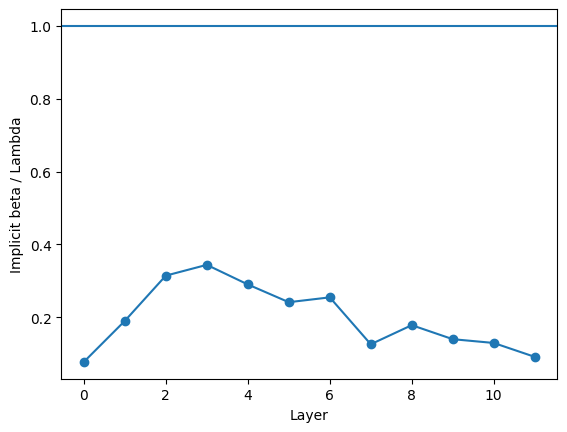

In [71]:
ratio=[
    b/l
    for b,l in zip(betas,lambdas)
]

plt.plot(
    ratio,
    marker="o"
)

plt.axhline(1)

plt.xlabel("Layer")
plt.ylabel("Implicit beta / Lambda")

plt.show()

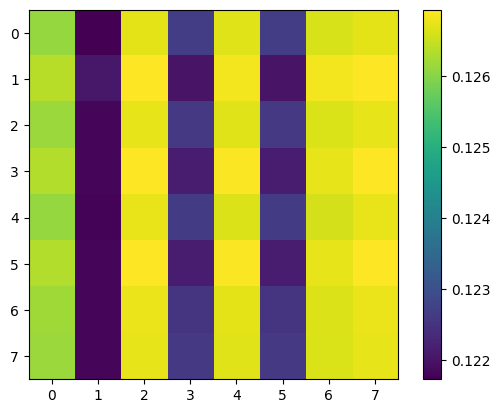

In [72]:
layer = model.layers[-1]

attention = torch.softmax(
    layer.attn.saved_logits/(64**0.5),
    dim=-1
)

plt.imshow(
    attention[0].numpy()
)

plt.colorbar()
plt.show()

In [73]:
x, y = generate_associative_batch(1)

print(x)
print("target:", y)

tensor([[ 1, 11,  5, 19,  0, 11, 20,  0]])
target: tensor([11])


In [74]:
layer = model.layers[-1]

attention = torch.softmax(
    layer.attn.saved_logits/(64**0.5),
    dim=-1
)

print(attention[0,-1])

tensor([0.1262, 0.1218, 0.1268, 0.1226, 0.1267, 0.1226, 0.1266, 0.1268])
